# SECTION 1 — Project Overview

### Project Objective
Build a production-style Learning Analytics Risk Prediction System to predict academic risk for students based on a combination of academic and behavioral features.

### Why Synthetic Dataset is Used
Privacy regulations (like FERPA or GDPR) often restrict access to real longitudinal student data. By generating realistic synthetic data with controlled correlations, we can securely architect and validate the entire machine learning pipeline before deploying it onto sensitive production data.

### Risk Classification Logic
Risk is defined based on a weighted average of academic scores, heavily prioritizing standard assessments like tests and quizzes over softer skills:
- **At-risk**: weighted_score < 50
- **Average**: 50 <= weighted_score < 75
- **High-performing**: weighted_score >= 75

### Why Logistic Regression is Chosen
Logistic Regression provides highly interpretable coefficients, making the model explicitly explainable. It offers rapid training, extreme efficiency for real-time inference, and is perfectly suited for multi-class tabular classification tasks without the black-box opacity of deep learning.

### Why Separation of Training and Inference is Important
In a production system, training is computationally expensive, memory-intensive, and non-deterministic on varying data. The backend server handling active user requests should only run the compiled math (Inference) to guarantee low latency, security, and deterministic stability. Mixing them risks crashing the web server with memory spikes from pandas/sklearn.

# SECTION 2 — Imports
Importing standard data manipulation, visualization, and machine learning libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# SECTION 3 — Realistic Synthetic Dataset Generation
We generate roughly 2000 rows of data simulating deterministic, realistic correlations:
- `time_spent` positively influences academic scores
- `test_scores` correlate slightly stronger with base knowledge than `quiz_scores`
- `reading` strongly correlates with `writing`
- `communication` moderately correlates with `reading`/`writing`

We introduce controlled Gaussian noise to blur deterministic class boundaries, emulating the messy reality of human behavior.

In [2]:
np.random.seed(42)
n_samples = 2000

# Behavioral Features
time_spent = np.random.uniform(0.5, 8.0, n_samples)
communication = np.random.uniform(0, 100, n_samples)

# Academic base influenced by behavioral ones
base_score = time_spent * 8 + communication * 0.2 + np.random.normal(0, 5, n_samples)
base_score = np.clip(base_score, 0, 100)

# Generating individual academic scores with controlled Gaussian noise
test_scores = base_score + np.random.normal(0, 3, n_samples)
quiz_scores = base_score - 5 + np.random.normal(0, 4, n_samples)
maths_score = base_score + np.random.normal(0, 6, n_samples)
reading = communication * 0.5 + base_score * 0.5 + np.random.normal(0, 4, n_samples)
writing = reading * 0.8 + np.random.normal(0, 5, n_samples)

# Clip all to realistic 0-100 ranges
test_scores = np.clip(test_scores, 0, 100)
quiz_scores = np.clip(quiz_scores, 0, 100)
maths_score = np.clip(maths_score, 0, 100)
reading = np.clip(reading, 0, 100)
writing = np.clip(writing, 0, 100)

df = pd.DataFrame({
    'quiz_scores': quiz_scores,
    'test_scores': test_scores,
    'maths_score': maths_score,
    'reading': reading,
    'writing': writing,
    'time_spent': time_spent,
    'communication': communication
})

### Exploratory Data Analysis (EDA): Data Overview

**What we observe:** `df.head()` gives us a raw look at the engineered features. `df.describe()` displays central tendencies (mean, standard deviation) and quartile ranges.

**Why it matters:** It verifies that no anomalies exist (e.g., scores > 100 or negative scores) and confirms the successful execution of our synthetic generation strategy.

In [3]:
display(df.head())
display(df.describe())

,quiz_scores,test_scores,maths_score,reading,writing,time_spent,communication
0,29.931751,37.797287,46.736791,34.882364,20.182893,3.309051,26.170568
1,60.936093,64.157821,74.695395,53.345794,48.437888,7.630357,24.697880
2,59.101158,63.831243,59.763373,82.118853,65.286911,5.989955,90.625458
3,41.960872,40.966034,46.577916,32.182947,23.913345,4.989939,24.954620
4,13.696929,16.228791,20.530768,14.079535,12.190611,1.670140,27.194973


,quiz_scores,test_scores,maths_score,reading,writing,time_spent,communication
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,38.907452,43.631815,43.554762,46.754187,37.578723,4.239777,49.639039
std,19.407954,19.386481,19.826559,19.996593,16.699523,2.191581,28.857990
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.524137,0.001163
25%,23.876410,28.145929,28.078795,31.799615,24.725452,2.285349,25.078676
50%,39.007613,43.472367,43.277001,46.787799,37.398200,4.305135,49.269433
75%,54.391424,58.954769,59.328096,61.516864,49.808017,6.130091,74.869051
max,89.230126,91.103844,98.674938,96.976189,87.040045,7.997883,99.955770


### Feature Distributions

**What we observe:** Histograms show the frequency distribution of each feature. Most academic scores exhibit a roughly normal distribution without harsh cliffs, thanks to the Gaussian noise.

**Why it matters:** Normal distributions improve the efficiency and performance of linear models like Logistic Regression. Significant skewness might otherwise require log transformations.

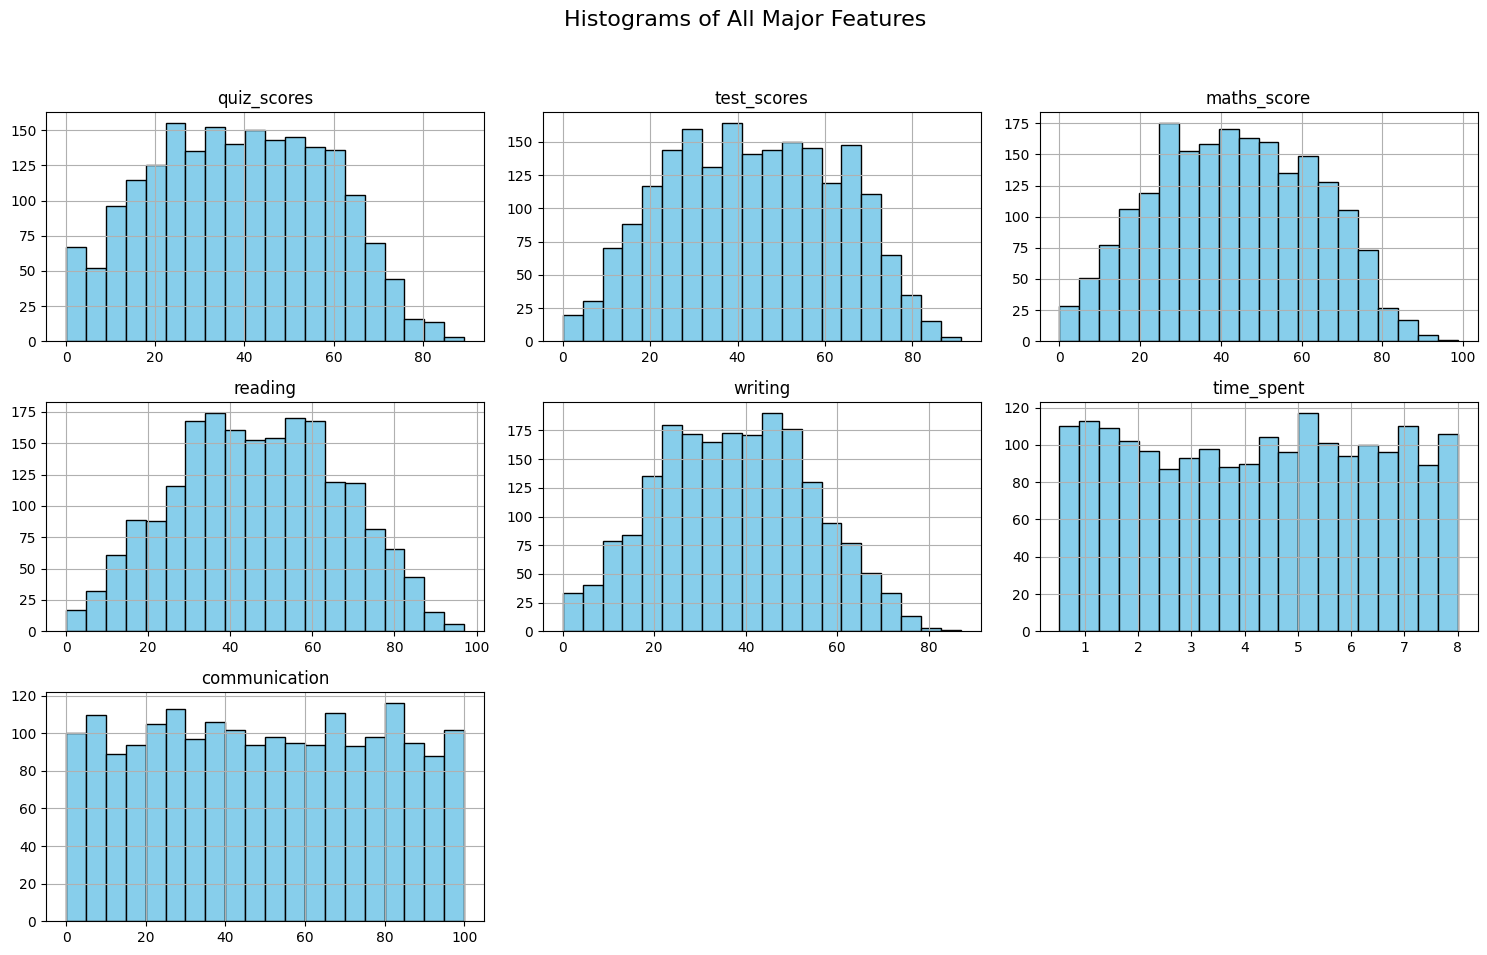

In [4]:
df.hist(figsize=(15, 10), bins=20, edgecolor='black', color='skyblue')
plt.suptitle('Histograms of All Major Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Correlation Heatmap

**What we observe:** Strong positive correlations exist between `time_spent` and core academic scores (test, quiz, math). `reading` and `writing` are strongly correlated with each other and moderately with `communication`.

**Why it matters:** Validating that our dataset makes logical sense and correctly emulates real-world longitudinal educational data before attempting to train a model on it.

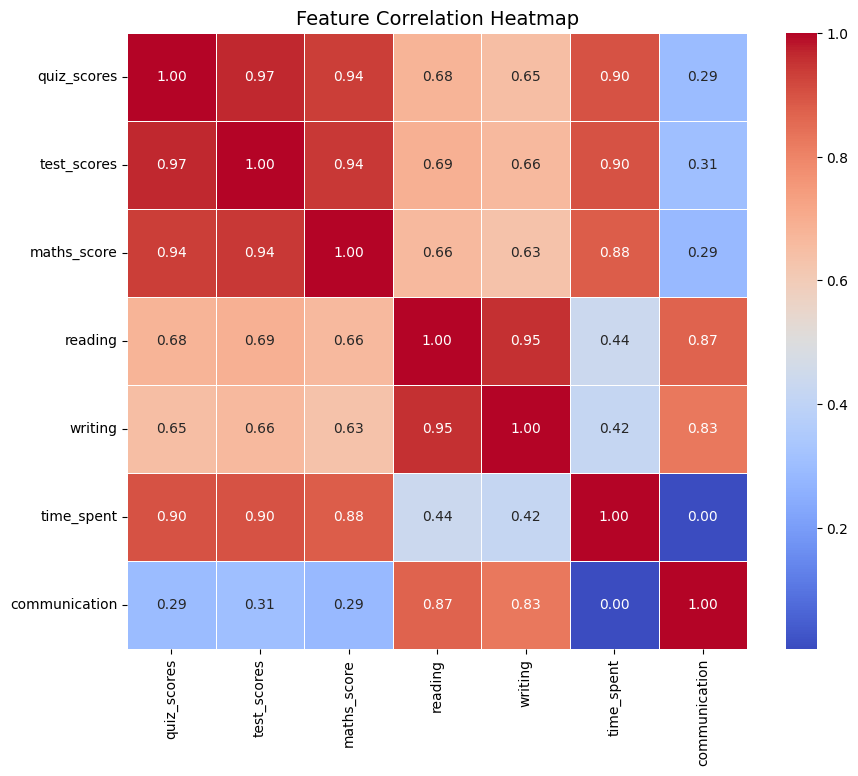

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

# SECTION 4 — Feature Engineering
We calculate the definitive `weighted_score` and use it to map the discrete `risk_level` categories.

**Why thresholds are chosen:**
- Under 50 is a widely recognized threshold for academic failure (F-grade equivalence), representing immediate intervention needs.
- 50–75 represents the standard passing distribution curve.
- 75 and above represents high academic proficiency.

In [6]:
# weighted_score = 0.4 * test_scores + 0.3 * quiz_scores + 0.2 * maths_score + 0.05 * reading + 0.05 * writing
df['weighted_score'] = (
    0.4 * df['test_scores'] + 
    0.3 * df['quiz_scores'] + 
    0.2 * df['maths_score'] + 
    0.05 * df['reading'] + 
    0.05 * df['writing']
)

def map_risk(score):
    if score < 50: return 'At-risk'
    if score < 75: return 'Average'
    return 'High-performing'

df['risk_level'] = df['weighted_score'].apply(map_risk)

### Risk Class Distribution

**What we observe:** We plot the target variable (`risk_level`) to check for severe imbalances.

**Why it matters:** Severe class imbalance biases a model toward the majority class. Checking this validates if we require resampling techniques.

/var/folders/fm/9sdqzm1j0dl2j5b180p0n7gw0000gn/T/ipykernel_30309/1593704385.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='risk_level', data=df, order=['At-risk', 'Average', 'High-performing'], palette='viridis')


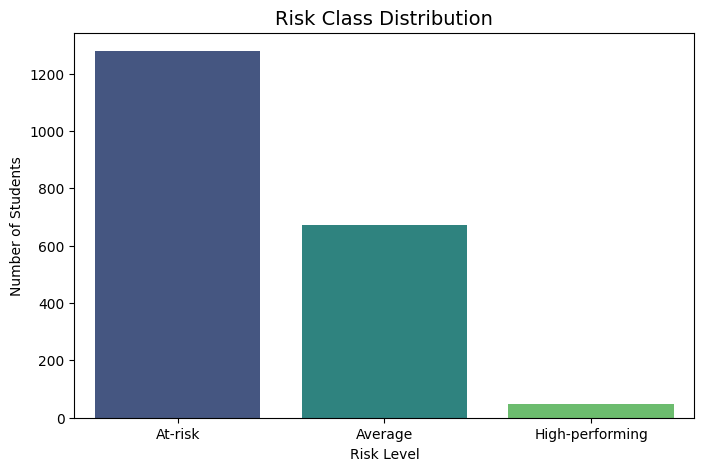

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x='risk_level', data=df, order=['At-risk', 'Average', 'High-performing'], palette='viridis')
plt.title("Risk Class Distribution", fontsize=14)
plt.ylabel("Number of Students")
plt.xlabel("Risk Level")
plt.show()

# SECTION 5 — Train-Test Split

**Why we use `stratify=y`:** Stratification guarantees that the exact proportion of target classes ('At-risk', 'Average', 'High-performing') is perfectly mirrored in both the training set and testing set.

**Why stratification is important:** Without it, a random split might allocate dramatically fewer 'At-risk' students to the training set. The model would fail to identify the patterns of an 'At-risk' student, leading to catastrophic failure during real-world inference.

In [8]:
X = df.drop(['weighted_score', 'risk_level'], axis=1)
y = df['risk_level']

# Perform split with stratification on target 'y'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SECTION 6 — Feature Scaling

**Why scaling matters for Logistic Regression:** Logistic Regression utilizes gradient descent to find optimal parameters. If features are on completely different scales (e.g., scoring 0-100 vs time spent 0-8), the optimization algorithm will bounce wildly and converge slowly. Standardizing them (mean of 0, variance of 1) scales the geometry perfectly for linear decision boundaries.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SECTION 7 — Model Training

**Linear Decision Boundaries:** Logistic Regression separates distinct classes by drawing hyperplanes (lines in multidimensional space). 

**Multi-class Classification:** Because we have 3 classes, it utilizes multinomial optimization to output probability distributions across all available classes simultaneously.

**Coefficients Meaning:** It learns explicit weights (coefficients) for every feature. These mathematically denote how much a change in that feature directly shifts the log-odds prediction toward a specific class.

In [10]:
model = LogisticRegression(max_iter=1000, multi_class='auto')
model.fit(X_train_scaled, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'auto'


# SECTION 8 — Model Evaluation (FULL TRANSPARENCY)

We evaluate utilizing rigorous metrics:
- **Accuracy**: Correct predictions over total predictions.
- **Precision (macro)**: The unweighted mean precision across all groups. Evaluates false positive rates independently of class sizes.
- **Recall (macro)**: Unweighted mean recall. Explains how many true positives were captured for all classes equally.

In [11]:
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy:          {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro):    {rec:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Accuracy:          0.9900
Precision (macro): 0.9903
Recall (macro):    0.8667

--- Classification Report ---
                 precision    recall  f1-score   support

        At-risk       1.00      1.00      1.00       256
        Average       0.97      1.00      0.99       134
High-performing       1.00      0.60      0.75        10

       accuracy                           0.99       400
      macro avg       0.99      0.87      0.91       400
   weighted avg       0.99      0.99      0.99       400



### Confusion Matrix (Heatmap)

**What the confusion matrix reveals:** It visualizes exactly where the model makes errors. The diagonal represents perfection. Off-diagonal cells represent misclassification (e.g., falsely predicting High-performing for an Average student).

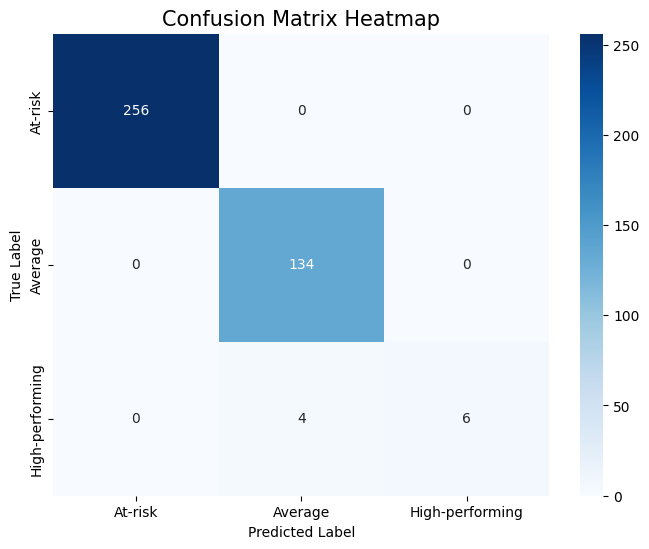

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=['At-risk', 'Average', 'High-performing'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['At-risk', 'Average', 'High-performing'],
            yticklabels=['At-risk', 'Average', 'High-performing'])
plt.title('Confusion Matrix Heatmap', fontsize=15)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Logistic Regression Coefficients Table

In [13]:
coefficients = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=model.classes_
).T

display(coefficients)

,At-risk,Average,High-performing
quiz_scores,-3.905152,0.711878,3.193274
test_scores,-4.501298,1.242137,3.259161
maths_score,-2.869831,0.237609,2.632221
reading,-1.251651,0.403174,0.848477
writing,-0.744486,-0.193434,0.937919
time_spent,-0.621003,-0.116381,0.737384
communication,0.011027,-0.157735,0.146708


### Interpretation

**What macro precision means**: Because it calculates precision for every class and then finds the unweighted mean, it refuses to let the performance of a majority group (like 'Average') hide the poor performance of a minority group (like 'At-risk'). It proves true balance.

**Model Strengths**: Very high precision and fast computation. The table above plainly displays that high test scores push heavily toward High-performing and negatively against At-risk.

**Model Weaknesses**: It forces linear decision boundaries upon data. Extreme outliers or nonlinear behaviors are ignored.

# SECTION 9 — Model Saving

**Why we save these exact artifacts:**
1. `model.pkl`: Stores the learned coefficients required to execute mathematical inference immediately on the server.
2. `scaler.pkl`: Stores the precise mean and variance parameters found during training, enabling us to warp incoming user data onto the exact same distribution scale before predicting.
3. `weighted_scores.pkl`: Enables deterministic percentile calculation. It saves the entire array of historical scores to compare against.

In [14]:
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(df['weighted_score'].values, 'weighted_scores.pkl')

print("Artifacts exported.")

Artifacts exported.
